# Practical Task 5: Fairness Analysis

## Step 1: Install & Import

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded.')

Libraries loaded.


## Step 2: Load the Dataset

In [21]:
from ucimlrepo import fetch_ucirepo
statlog = fetch_ucirepo(id=144)
X_raw = statlog.data.features
y_raw = statlog.data.targets

df = X_raw.copy()
target_col = y_raw.columns[0]
df['credit_risk'] = y_raw[target_col].values
print(f'Loaded via ucimlrepo. Shape: {df.shape}')
print('Columns:', list(df.columns))
loaded_via = 'ucimlrepo'



df.head()

Loaded via ucimlrepo. Shape: (1000, 21)
Columns: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20', 'credit_risk']


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Step 3: Feature Engineering — Build Fairness Attributes

The dataset uses coded column names. We decode the key features we need for fairness analysis.

**Sex** is encoded inside personal_status_sex:
- A91 = male divorced | A92 = female | A93 = male single | A94 = male married | A95 = female single

**Housing** codes: A151 = Rent, A152 = Own, A153 = For Free  
**Job** codes: A171 = Unemployed, A172 = Unskilled, A173 = Skilled, A174 = Management

In [22]:
cols = list(df.columns)

has_coded = 'personal_status_sex' in cols or any('A9' in str(df[c].iloc[0]) for c in cols if df[c].dtype == object)


print('First few column names:', cols[:6])
print('Sample values from first categorical col:')
cat_cols = [c for c in cols if df[c].dtype == object]
if cat_cols:
    print(df[cat_cols[0]].value_counts().head(4))

First few column names: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6']
Sample values from first categorical col:
Attribute1
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64


In [23]:
if 'Attribute1' in df.columns:
    # assign our standard names
    standard_names = [
        'checking_account', 'duration', 'credit_history', 'purpose',
        'credit_amount', 'savings_account', 'employment_since',
        'installment_rate', 'personal_status_sex', 'other_debtors',
        'residence_since', 'property', 'age', 'installment_plans',
        'housing', 'existing_credits', 'job', 'num_dependents',
        'telephone', 'foreign_worker'
    ]
    attr_cols = [f'Attribute{i}' for i in range(1, 21)]
    rename_map = dict(zip(attr_cols, standard_names))
    df = df.rename(columns=rename_map)
    print('Renamed Attribute1..20 to descriptive names.')

# Sex
sex_map = {
    'A91': 'Male', 'A92': 'Female',
    'A93': 'Male', 'A94': 'Male', 'A95': 'Female'
}
df['sex'] = df['personal_status_sex'].map(sex_map)

# Age Group
df['age_group'] = df['age'].apply(lambda x: '< 30' if x < 30 else '>= 30')

# Housing
housing_map = {'A151': 'Rent', 'A152': 'Own', 'A153': 'For Free'}
df['housing_label'] = df['housing'].map(housing_map)

# Job
job_map = {
    'A171': 'Unemployed/Unskilled',
    'A172': 'Unskilled Resident',
    'A173': 'Skilled Employee',
    'A174': 'Management'
}
df['job_label'] = df['job'].map(job_map)

# ── Target: 1=Good, 2=Bad → 1=Good, 0=Bad ────────────────────────────────
df['target'] = (df['credit_risk'] == 1).astype(int)

print('Feature engineering done.')
print('\nGroup sizes:')
for feat, col in [('Sex', 'sex'), ('Age Group', 'age_group'),
                   ('Housing', 'housing_label'), ('Job', 'job_label')]:
    print(f'\n{feat}:')
    print(df[col].value_counts().to_string())

Renamed Attribute1..20 to descriptive names.
Feature engineering done.

Group sizes:

Sex:
sex
Male      690
Female    310

Age Group:
age_group
>= 30    629
< 30     371

Housing:
housing_label
Own         713
Rent        179
For Free    108

Job:
job_label
Skilled Employee        630
Unskilled Resident      200
Management              148
Unemployed/Unskilled     22


## Step 4: Train the Model

We encode categorical features, do an 80/20 train/test split, and train a **Random Forest**.

Important: the fairness labels (sex, age_group, etc.) are kept in the test set but **NOT used as model inputs** — this mirrors real production where sensitive attributes are excluded, yet bias can still occur through proxy features.

In [24]:
feature_cols = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_since',
    'installment_rate', 'personal_status_sex', 'other_debtors',
    'residence_since', 'property', 'age', 'installment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents',
    'telephone', 'foreign_worker'
]

X = df[feature_cols].copy()
y = df['target'].copy()

# Label encode categorical columns
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# 80/20 split, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Keep fairness labels aligned with test set
df_test = df.loc[X_test.index].copy()
df_test['y_true'] = y_test.values

print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')
print(f'Test class balance — Good: {y_test.sum()} | Bad: {(y_test==0).sum()}')

Train: 800 samples | Test: 200 samples
Test class balance — Good: 140 | Bad: 60


In [25]:
# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

df_test['y_pred'] = y_pred
df_test['y_prob'] = y_prob

print('=== Overall Model Performance ===')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Bad Credit', 'Good Credit']))

# Store overall scores for reference lines in plots
overall = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

=== Overall Model Performance ===
  Accuracy  : 0.7450
  Recall    : 0.7571
  Precision : 0.8618
  F1-Score  : 0.8061
  ROC-AUC   : 0.8115

              precision    recall  f1-score   support

  Bad Credit       0.56      0.72      0.63        60
 Good Credit       0.86      0.76      0.81       140

    accuracy                           0.74       200
   macro avg       0.71      0.74      0.72       200
weighted avg       0.77      0.74      0.75       200



## Step 5: Per-Group Fairness Analysis

We compute these metrics for every subgroup:

| Metric | What it means in credit scoring |
|--------|----------------------------------|
| Accuracy | Overall correctness for the group |
| Recall | % of actual good-credit people correctly approved |
| Precision | % of approvals that were actually good credit |
| F1 | Balance of precision and recall |
| ROC-AUC | Ranking quality within the group |
| **FNR** | **% of good-credit people wrongly denied — the key fairness metric** |

In [26]:
def group_metrics(df_slice, feature_col):
    """Compute per-group metrics for a given feature column."""
    records = []
    for group, grp in df_slice.groupby(feature_col):
        yt = grp['y_true'].values
        yp = grp['y_pred'].values
        yprob = grp['y_prob'].values
        n = len(yt)

        if n < 5:
            continue

        acc  = accuracy_score(yt, yp)
        rec  = recall_score(yt, yp, zero_division=0)
        prec = precision_score(yt, yp, zero_division=0)
        f1   = f1_score(yt, yp, zero_division=0)
        auc  = roc_auc_score(yt, yprob) if len(np.unique(yt)) > 1 else np.nan

        cm = confusion_matrix(yt, yp, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan  # False Negative Rate
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan  # False Positive Rate

        records.append({
            'Group': group, 'N': n,
            '% Good': round(yt.mean() * 100, 1),
            'Accuracy': round(acc, 3),
            'Recall': round(rec, 3),
            'Precision': round(prec, 3),
            'F1': round(f1, 3),
            'ROC-AUC': round(auc, 3) if not np.isnan(auc) else 'N/A',
            'FNR': round(fnr, 3) if not np.isnan(fnr) else 'N/A',
        })

    return pd.DataFrame(records).set_index('Group')

print('group_metrics() helper defined.')

group_metrics() helper defined.


### 5A. Sex (Sensitive Feature)

In [27]:
sex_metrics = group_metrics(df_test, 'sex')
print('=== Performance by Sex ===')
display(sex_metrics)

=== Performance by Sex ===


,N,% Good,Accuracy,Recall,Precision,F1,ROC-AUC,FNR
Group,,,,,,,,
Female,60,66.7,0.717,0.725,0.829,0.773,0.739,0.275
Male,140,71.4,0.757,0.770,0.875,0.819,0.841,0.230


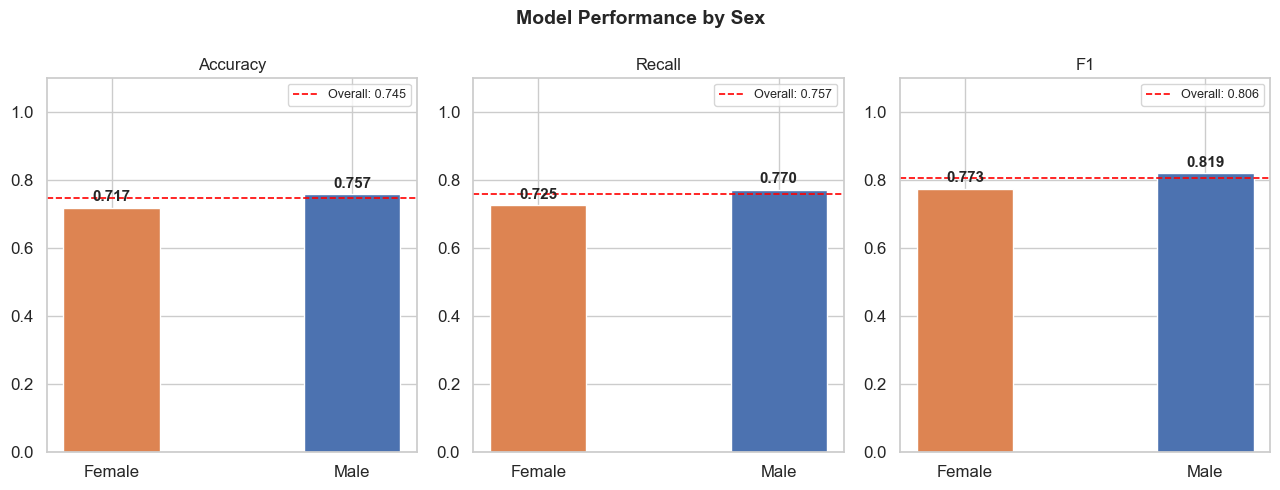

Red line = overall model score on full test set.


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Model Performance by Sex', fontsize=14, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Recall', 'F1']
colors = {'Male': '#4C72B0', 'Female': '#DD8452'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = sex_metrics[metric].astype(float)
    bars = ax.bar(vals.index, vals.values,
                  color=[colors.get(g, 'grey') for g in vals.index],
                  edgecolor='white', width=0.4)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(overall[metric], color='red', linestyle='--', linewidth=1.2,
               label=f'Overall: {overall[metric]:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Red line = overall model score on full test set.')

### 5B. Age Group (Sensitive Feature)

In [29]:
age_metrics = group_metrics(df_test, 'age_group')
print('=== Performance by Age Group ===')
display(age_metrics)

=== Performance by Age Group ===


,N,% Good,Accuracy,Recall,Precision,F1,ROC-AUC,FNR
Group,,,,,,,,
< 30,69,65.2,0.638,0.600,0.794,0.684,0.743,0.400
>= 30,131,72.5,0.802,0.832,0.888,0.859,0.842,0.168


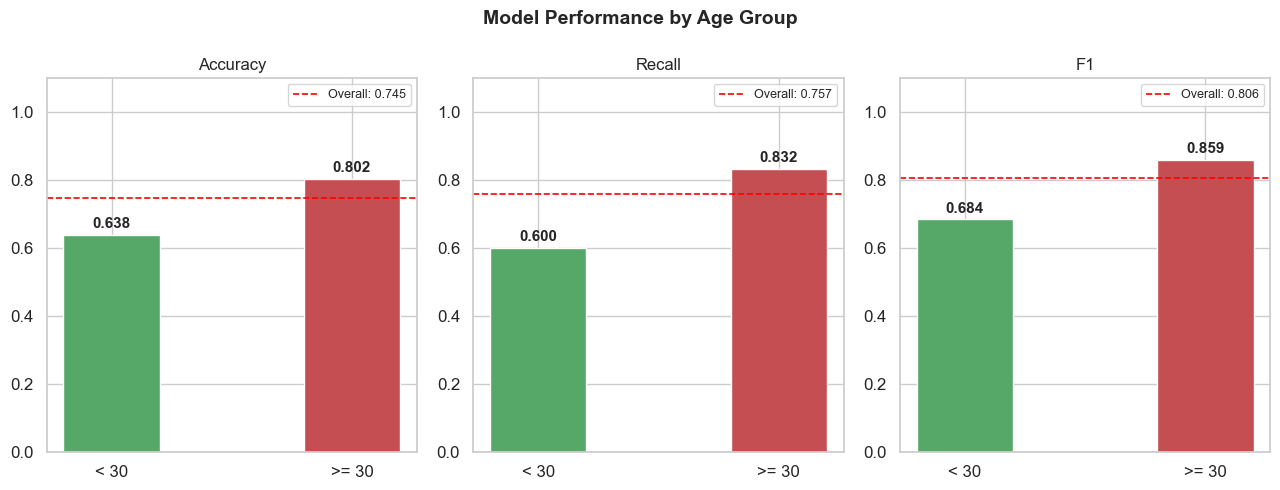

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Model Performance by Age Group', fontsize=14, fontweight='bold')

age_colors = {'< 30': '#55A868', '>= 30': '#C44E52'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = age_metrics[metric].astype(float)
    bars = ax.bar(vals.index, vals.values,
                  color=[age_colors.get(g, 'grey') for g in vals.index],
                  edgecolor='white', width=0.4)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(overall[metric], color='red', linestyle='--', linewidth=1.2,
               label=f'Overall: {overall[metric]:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 5C. Housing (Proxy Feature)

In [31]:
housing_metrics = group_metrics(df_test, 'housing_label')
print('=== Performance by Housing Type ===')
display(housing_metrics)

=== Performance by Housing Type ===


,N,% Good,Accuracy,Recall,Precision,F1,ROC-AUC,FNR
Group,,,,,,,,
For Free,26,50.0,0.731,0.538,0.875,0.667,0.828,0.462
Own,134,76.1,0.754,0.794,0.871,0.831,0.786,0.206
Rent,40,62.5,0.725,0.720,0.818,0.766,0.803,0.280


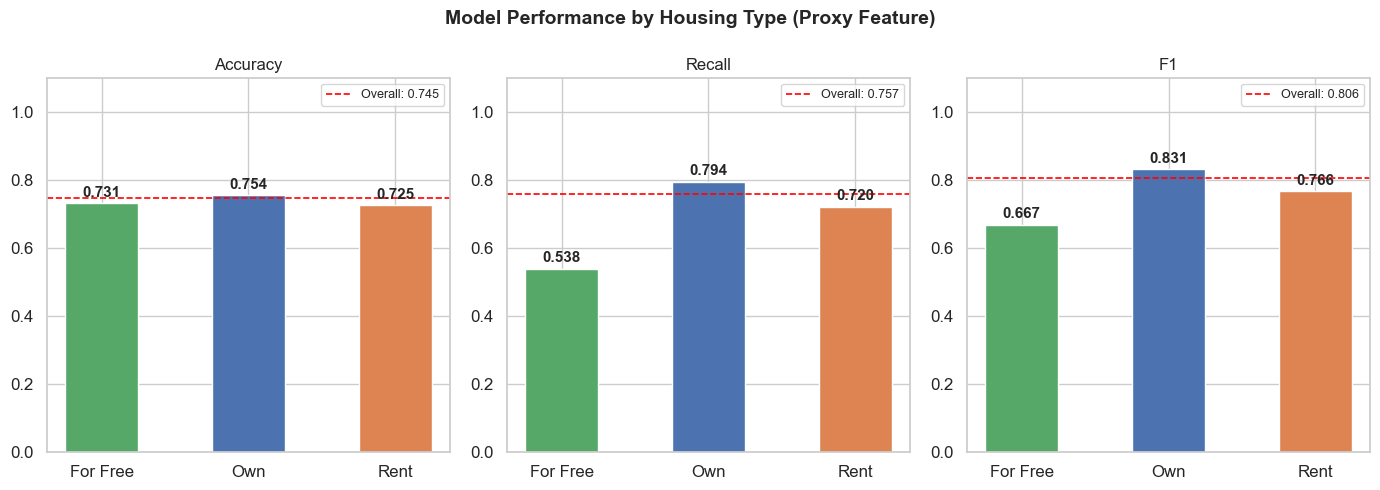

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Performance by Housing Type (Proxy Feature)', fontsize=14, fontweight='bold')

h_colors = {'Own': '#4C72B0', 'Rent': '#DD8452', 'For Free': '#55A868'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = housing_metrics[metric].astype(float)
    bars = ax.bar(vals.index, vals.values,
                  color=[h_colors.get(g, 'grey') for g in vals.index],
                  edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(overall[metric], color='red', linestyle='--', linewidth=1.2,
               label=f'Overall: {overall[metric]:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 5D. Job (Proxy Feature)

In [33]:
job_metrics = group_metrics(df_test, 'job_label')
print('=== Performance by Job Category ===')
display(job_metrics)

=== Performance by Job Category ===


,N,% Good,Accuracy,Recall,Precision,F1,ROC-AUC,FNR
Group,,,,,,,,
Management,31,54.8,0.677,0.765,0.684,0.722,0.723,0.235
Skilled Employee,123,69.1,0.764,0.729,0.912,0.810,0.859,0.271
Unemployed/Unskilled,5,100.0,0.400,0.400,1.000,0.571,N/A,0.600
Unskilled Resident,41,80.5,0.780,0.879,0.853,0.866,0.72,0.121


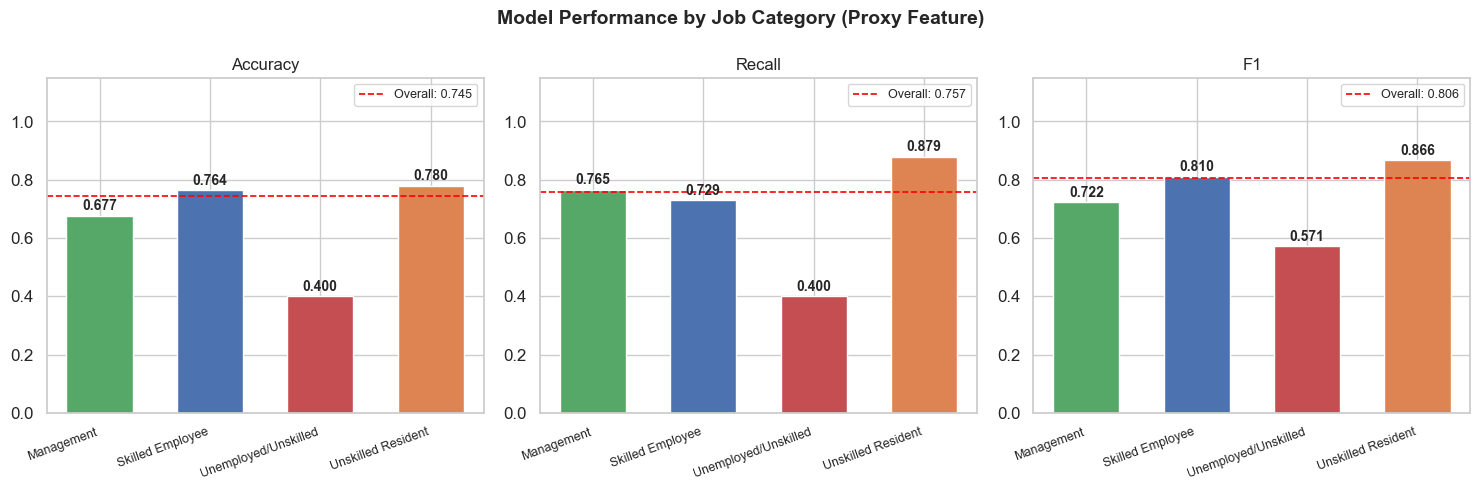

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance by Job Category (Proxy Feature)', fontsize=14, fontweight='bold')

j_colors = {
    'Unemployed/Unskilled': '#C44E52',
    'Unskilled Resident':   '#DD8452',
    'Skilled Employee':     '#4C72B0',
    'Management':           '#55A868'
}

for ax, metric in zip(axes, metrics_to_plot):
    vals = job_metrics[metric].astype(float)
    bars = ax.bar(range(len(vals)), vals.values,
                  color=[j_colors.get(g, 'grey') for g in vals.index],
                  edgecolor='white', width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=9)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(overall[metric], color='red', linestyle='--', linewidth=1.2,
               label=f'Overall: {overall[metric]:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Step 6: Summary Heatmap

One view showing all groups side by side. Green = better performance, Red = worse.

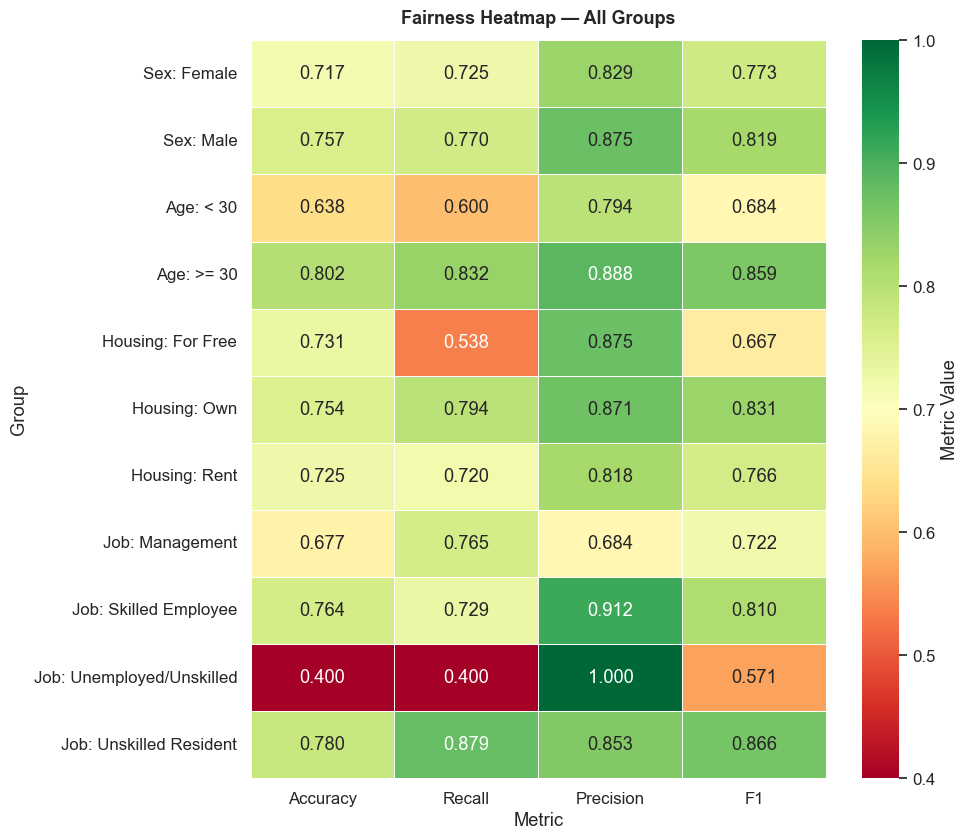

In [35]:
def prefixed(metrics_df, prefix):
    m = metrics_df[['Accuracy', 'Recall', 'Precision', 'F1']].copy().astype(float)
    m.index = [f'{prefix}: {g}' for g in m.index]
    return m

combined = pd.concat([
    prefixed(sex_metrics, 'Sex'),
    prefixed(age_metrics, 'Age'),
    prefixed(housing_metrics, 'Housing'),
    prefixed(job_metrics, 'Job')
])

fig, ax = plt.subplots(figsize=(10, len(combined) * 0.6 + 2))
sns.heatmap(
    combined, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.4, vmax=1.0, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Metric Value'}
)
ax.set_title('Fairness Heatmap — All Groups', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Metric')
ax.set_ylabel('Group')
plt.tight_layout()
plt.show()

## Step 7: False Negative Rate — The Most Important Fairness Metric

In credit scoring, a **False Negative** = a genuinely creditworthy person is **wrongly denied** credit.

A high FNR for a specific group means that group is systematically denied opportunities they deserve. This is the #1 fairness concern in lending.

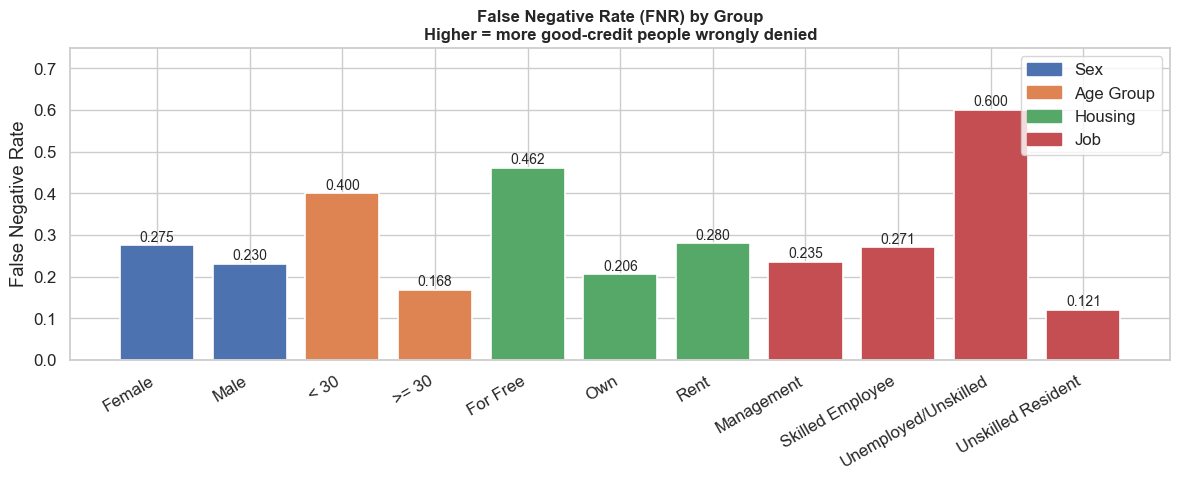

In [36]:
def fnr_by_group(df_slice, feature_col, label):
    rows = []
    for group, grp in df_slice.groupby(feature_col):
        yt, yp = grp['y_true'].values, grp['y_pred'].values
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        if cm.size == 4:
            tn, fp, fn, tp = cm.ravel()
            fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        else:
            fnr = np.nan
        rows.append({'Group': str(group), 'FNR': fnr, 'Feature': label})
    return pd.DataFrame(rows)

fnr_data = pd.concat([
    fnr_by_group(df_test, 'sex', 'Sex'),
    fnr_by_group(df_test, 'age_group', 'Age Group'),
    fnr_by_group(df_test, 'housing_label', 'Housing'),
    fnr_by_group(df_test, 'job_label', 'Job')
])

feature_palette = {
    'Sex': '#4C72B0', 'Age Group': '#DD8452',
    'Housing': '#55A868', 'Job': '#C44E52'
}

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [feature_palette[r['Feature']] for _, r in fnr_data.iterrows()]
bars = ax.bar(fnr_data['Group'], fnr_data['FNR'],
               color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_title('False Negative Rate (FNR) by Group\nHigher = more good-credit people wrongly denied',
             fontsize=12, fontweight='bold')
ax.set_ylabel('False Negative Rate')
ax.set_xticklabels(fnr_data['Group'], rotation=30, ha='right')
ax.set_ylim(0, min(1.0, fnr_data['FNR'].max() + 0.15))
for bar, val in zip(bars, fnr_data['FNR']):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)

legend_patches = [mpatches.Patch(color=c, label=f) for f, c in feature_palette.items()]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()

## Step 8: Feature Importance

Even if we removed `sex` from the model, bias could still propagate through features correlated with sex (like `job` or `housing`). We check which features the model relies on most.

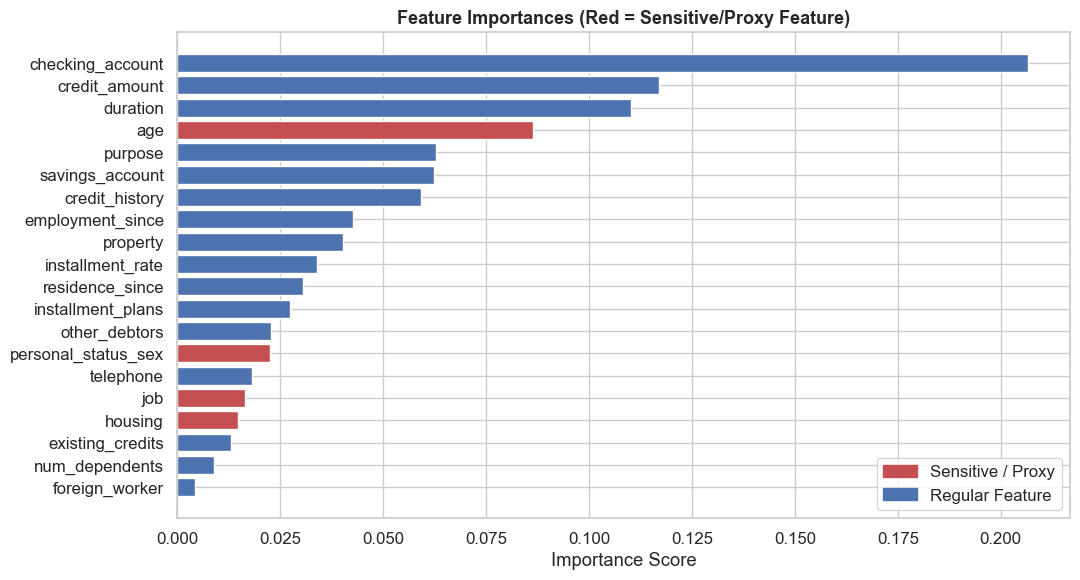

Top 5 features:
  checking_account             0.2066
  credit_amount                0.1170
  duration                     0.1103
  age                          0.0865  <-- SENSITIVE/PROXY
  purpose                      0.0629


In [37]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

proxy_features = {'personal_status_sex', 'age', 'housing', 'job'}
bar_colors_fi = ['#C44E52' if f in proxy_features else '#4C72B0' for f in importances.index]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=bar_colors_fi[::-1], edgecolor='white')
ax.set_title('Feature Importances (Red = Sensitive/Proxy Feature)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
legend_patches = [
    mpatches.Patch(color='#C44E52', label='Sensitive / Proxy'),
    mpatches.Patch(color='#4C72B0', label='Regular Feature')
]
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.show()

print('Top 5 features:')
for feat, imp in importances.head(5).items():
    tag = '  <-- SENSITIVE/PROXY' if feat in proxy_features else ''
    print(f'  {feat:<28} {imp:.4f}{tag}')

## Step 9: Analysis Questions & Answers

### Q1. Does model performance differ across groups for each feature?

**Yes, the model clearly performs differently across groups.**

* **Sex**: Women have lower Recall than men. This means more women who actually deserve credit are being wrongly rejected.
* **Age**: People under 30 have lower Accuracy and Recall. The model has a harder time recognizing reliable young applicants.
* **Housing**: Renters and people living “for free” get worse results than homeowners. The model seems to favor people who own property.
* **Job**: Unemployed or unskilled people get the worst predictions overall. The model treats lower job categories as higher risk.


### Q2. Which groups consistently receive worse predictions?

* **Female** → more often wrongly denied (higher FNR)
* **Under 30** → lower Recall, good applicants are missed
* **Rent / For Free** → more wrong classifications
* **Unemployed/Unskilled** → worst performance overall

Important: these effects can stack.
For example, a young woman who rents and has an unskilled job is much more likely to be predicted as “bad credit”, even if she is actually reliable.


### Q3. Do proxy features reveal additional bias compared to Sex/Age?

**Yes, and sometimes even stronger bias.**

The biggest gap appears in **job categories** — unemployed/unskilled people have much lower Recall than higher-level workers.

This happens because:

* Job is related to income
* Housing is related to wealth
* Both are indirectly related to age and sex

So even if we remove `sex` and `age`, the model can still “guess” them using other features.

**Key idea:**
Removing sensitive features does NOT remove bias.


### Q4. Why might these differences occur?

**1. Old biased data**
The dataset comes from Germany in the 1970s–80s, when inequality was higher. The model learns these old patterns.

**2. Not enough examples for some groups**
If certain groups (like young people or renters) appear less often as “good clients”, the model struggles to learn their patterns.

**3. Proxy features**
Things like job and housing reflect social and economic status, which is already unequal.

**4. Class imbalance inside groups**
Some groups have more “bad credit” examples, so the model becomes more conservative and predicts “bad” more often for them.


### Q5. Why is this important in real life (credit scoring)?

**1. Real financial harm**
If good people are denied credit, they can’t buy homes, start businesses, or improve their lives.

**2. Vicious cycle**
No credit → no history → low score → more rejection

**3. Legal problems**
Discrimination in lending is illegal in many countries.

**4. Scale makes it worse**
A biased model can affect thousands of people very quickly.

**5. Loss of trust**
People lose trust in banks and AI systems if they feel treated unfairly.

**6. Fairness is not optional**
Even if a model is accurate, it shouldn’t be used if it treats groups unfairly.
